Objective

The objective of this analysis is to study the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader performance using Hyperliquid historical trading data.

Methodology

1. Loaded both datasets.
2. Converted date columns to datetime format.
3. Merged datasets on date.
4. Performed exploratory data analysis.
5. Compared profitability, win rate, trade size and trading behavior across different sentiment conditions.

Dataset Description

1. Historical Trader Data:
   Contains trade-level information such as account, coin, execution price, trade size, fees, and realized profit/loss.

2. Fear & Greed Index:
   Represents Bitcoin market sentiment categorized as Extreme Fear, Fear, Neutral, Greed, and Extreme Greed.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [6]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print("Trades Shape :", trades.shape)
print("Sentiment Shape :", sentiment.shape)

Trades Shape : (211224, 16)
Sentiment Shape : (2644, 4)


In [7]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [8]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [9]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [10]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [11]:
print(trades.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [12]:
print(sentiment.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64


In [13]:
trades['date'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True,
    format='mixed'
).dt.date

sentiment['date'] = pd.to_datetime(
    sentiment['date']
).dt.date

In [14]:
merged = pd.merge(
    trades,
    sentiment[['date','classification']],
    on='date',
    how='left'
)

print(merged.shape)
merged.head()

(211224, 18)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [15]:
merged['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


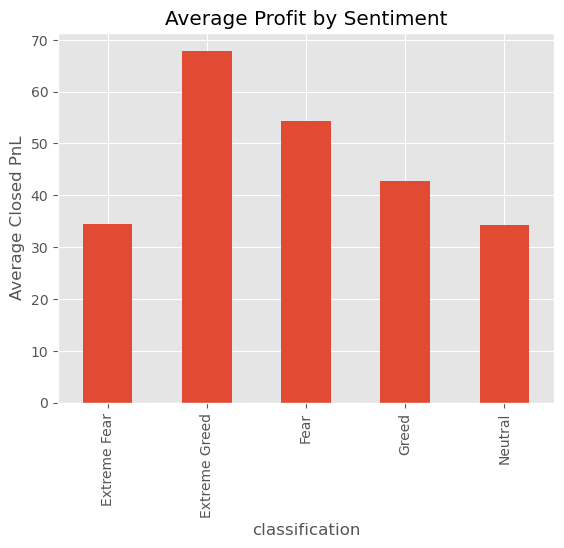

In [16]:
avg_profit = merged.groupby(
    'classification'
)['Closed PnL'].mean()

print(avg_profit)

avg_profit.plot(kind='bar')
plt.title("Average Profit by Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: win, dtype: float64


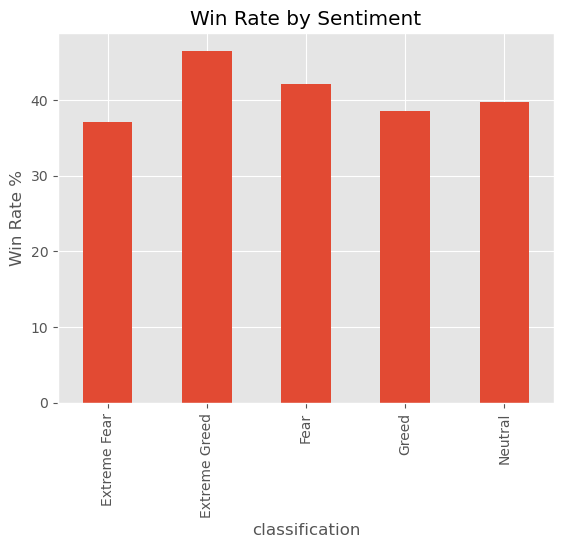

In [17]:
merged['win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby(
    'classification'
)['win'].mean()*100

print(win_rate)

win_rate.plot(kind='bar')
plt.title("Win Rate by Sentiment")
plt.ylabel("Win Rate %")
plt.show()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


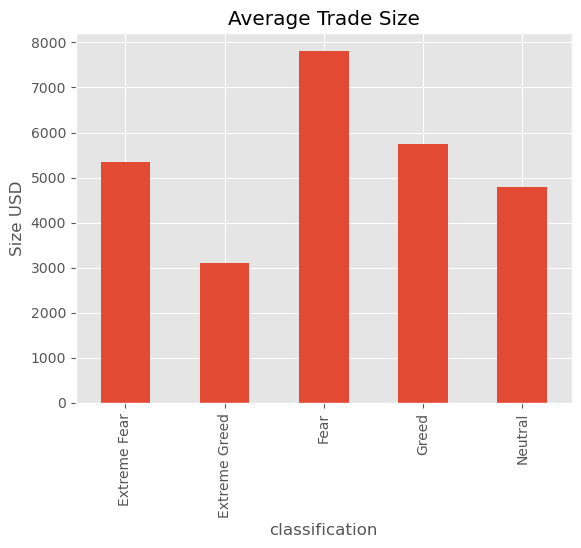

In [18]:
trade_size = merged.groupby(
    'classification'
)['Size USD'].mean()

print(trade_size)

trade_size.plot(kind='bar')
plt.title("Average Trade Size")
plt.ylabel("Size USD")
plt.show()

classification
Extreme Fear     1.116291
Extreme Greed    0.675902
Fear             1.495172
Greed            1.254372
Neutral          1.044798
Name: Fee, dtype: float64


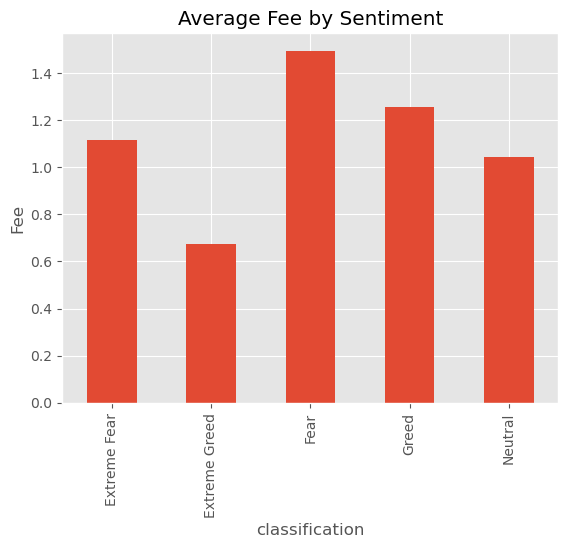

In [21]:
avg_fee = merged.groupby(
    'classification'
)['Fee'].mean()

print(avg_fee)

avg_fee.plot(kind='bar')
plt.title("Average Fee by Sentiment")
plt.ylabel("Fee")
plt.show()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


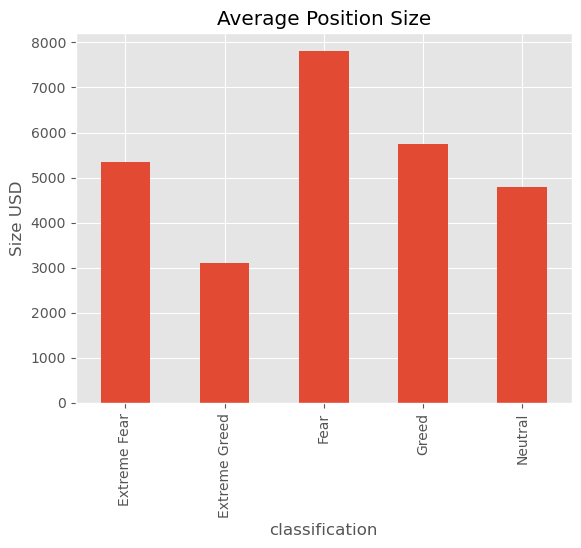

In [22]:
avg_size = merged.groupby(
    'classification'
)['Size USD'].mean()

print(avg_size)

avg_size.plot(kind='bar')
plt.title("Average Position Size")
plt.ylabel("Size USD")
plt.show()

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


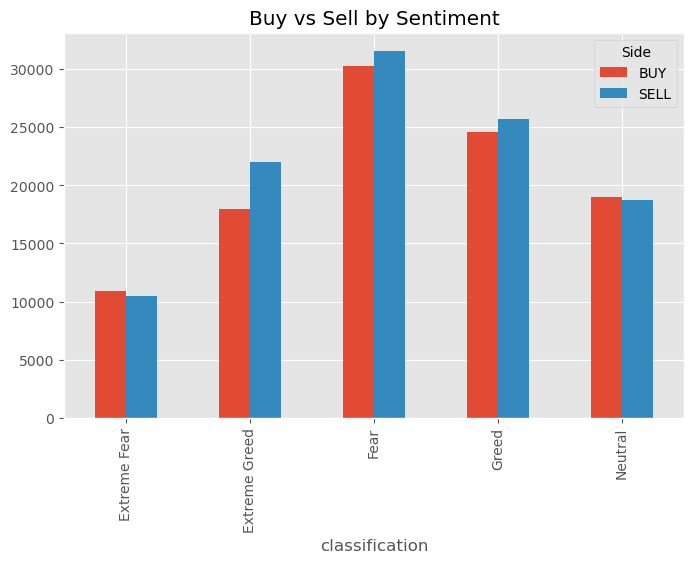

In [23]:
trade_behavior = pd.crosstab(
    merged['classification'],
    merged['Side']
)

print(trade_behavior)

trade_behavior.plot(kind='bar', figsize=(8,5))
plt.title("Buy vs Sell by Sentiment")
plt.show()

In [24]:
coin_profit = merged.groupby(
    'Coin'
)['Closed PnL'].sum()

coin_profit = coin_profit.sort_values(
    ascending=False
)

print(coin_profit.head(10))

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64


In [25]:
pivot_table = pd.pivot_table(
    merged,
    values='Closed PnL',
    index='Coin',
    columns='classification',
    aggfunc='mean'
)

print(pivot_table.head())

classification  Extreme Fear  Extreme Greed      Fear      Greed    Neutral
Coin                                                                       
@1                       NaN      18.358058  0.000000   0.179780        NaN
@10                -0.031742            NaN  0.000000   0.000000        NaN
@100                     NaN       6.906785       NaN        NaN        NaN
@103                     NaN       6.812669       NaN   2.247346        NaN
@107              -89.588788     191.158211 -2.291257  86.251763  52.150107


In [26]:
top_traders = merged.groupby(
    'Account'
)['Closed PnL'].sum()

top_traders = top_traders.sort_values(
    ascending=False
)

print(top_traders.head(10))

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


In [27]:
bottom_traders = merged.groupby(
    'Account'
)['Closed PnL'].sum()

bottom_traders = bottom_traders.sort_values()

print(bottom_traders.head(10))

Account
0x8170715b3b381dffb7062c0298972d4727a0a63b   -167621.124781
0x271b280974205ca63b716753467d5a371de622ab    -70436.191318
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    -31203.599986
0x39cef799f8b69da1995852eea189df24eb5cae3c     14456.919336
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f     14900.443047
0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb     21758.831753
0xb899e522b5715391ae1d4f137653e7906c5e2115     22488.500821
0x8477e447846c758f5a675856001ea72298fd9cb5     43917.008976
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     47885.320514
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6     53496.247243
Name: Closed PnL, dtype: float64


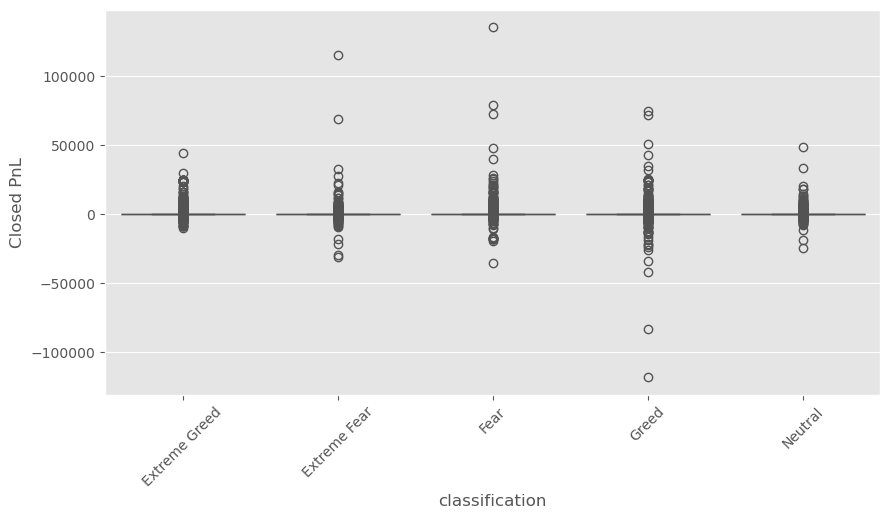

In [28]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.xticks(rotation=45)
plt.show()

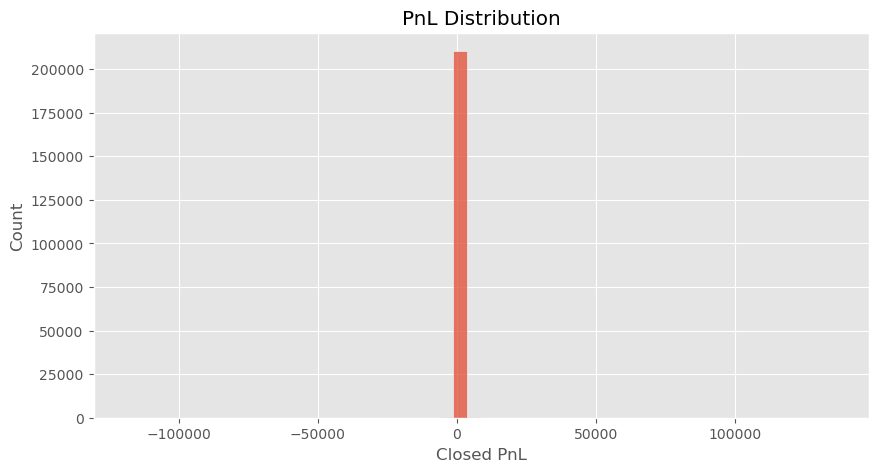

In [29]:
plt.figure(figsize=(10,5))

sns.histplot(
    merged['Closed PnL'],
    bins=50
)

plt.title("PnL Distribution")
plt.show()

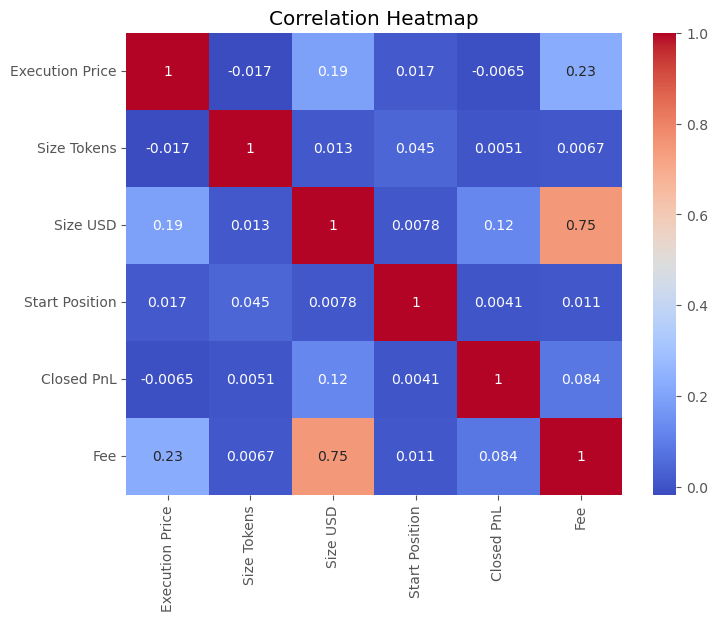

In [32]:
cols = [
    'Execution Price',
    'Size Tokens',
    'Size USD',
    'Start Position',
    'Closed PnL',
    'Fee'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    merged[cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

classification
Extreme Fear     1136.056091
Extreme Greed     766.828294
Fear              935.355438
Greed            1116.028390
Neutral           517.122220
Name: Closed PnL, dtype: float64


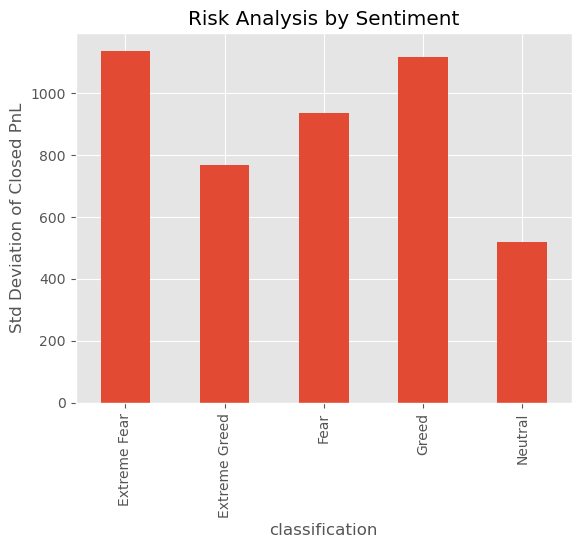

In [31]:
risk = merged.groupby(
    'classification'
)['Closed PnL'].std()

print(risk)

risk.plot(kind='bar')
plt.title("Risk Analysis by Sentiment")
plt.ylabel("Std Deviation of Closed PnL")
plt.show()

Key Findings

1. Extreme Greed periods showed the highest average profitability.

2. Fear periods had larger average trade sizes.

3. Extreme Fear periods showed higher volatility and risk.

4. Win rate was highest during Extreme Greed market conditions.

5. Trading behavior changes significantly with market sentiment.

6. Market sentiment can be used as an additional feature for trading decisions.

Conclusion

The analysis shows that market sentiment has a noticeable impact on trader behavior and performance.
Extreme Greed periods resulted in the highest average profitability and win rates, while Extreme Fear periods were associated with higher volatility and risk.
The findings suggest that sentiment indicators such as the Fear & Greed Index can provide useful context when evaluating trading strategies and managing risk.